In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#只在 Jupyter Notebook / IPython 里有效
# matplotlib 画的图内嵌显示在 notebook 输出里，而不是弹出一个独立窗口。

In [2]:
#第一版，直接计算Value类型变量。
class Value:

    def __init__(self, data):
        self.data = data

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data)
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data)
        return out

a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d

Value(data=4.0)

In [3]:
#第二版，为了知道结果的子节点有哪些，设置了_children，并将其放入集合_prev中
class Value:

    def __init__(self, data, _children=()):
        self.data = data
        self._prev = set(_children)

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other))
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other))
        return out

a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
#out1 = a.__mul__(b) → out1.data = -6.0，out1._prev = {a, b}
#out2 = out1.__add__(c) → out2.data = 4.0，out2._prev = {out1, c}
#注意：set(可迭代对象) 会把可迭代对象里的每个元素放进去。
#可以理解为每次进行乘法或者加法运算，那么会将自身以及另一个运算数存入运算结果的_prev()中
d = a * b + c
d

Value(data=4.0)

In [4]:
#第三版，为了知道结果的字节点有哪些，设置了_children，并将其放入集合_prev中。
#但是仍然不知道子节点进行了何种操作得出父节点，因此再添加一个_op。
#为了便于可视化，增加标签label，方便理解变量计算过程。
#为了实现梯度计算，计算出损失函数对于各个权重的导数，增加grad。
#为了实现自动进行梯度计算，增加函数backward
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad=0.0
        self._backward=lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1*out.grad
            other.grad += 1*out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ))
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e=a*b;e.label='e'
d = e + c;d.label='d'
f = Value(-2.0, label='f')
L = d * f;L.label='L'
d._prev
d._op

'+'

In [5]:
#上面代码构建了一个数据结构，可以了解由哪些元素进行了何种运算，构成现在的结果
#但是对于过于复杂的数学表达式，无法直观看出，因此需要可视化帮助
import os
os.environ["PATH"] = r"E:\develop\Graphviz\bin" + os.pathsep + os.environ["PATH"]
from graphviz import Digraph
#从 root 开始，深度优先遍历整个图。root在此处表示运算的终点
def trace(root):
    #nodes收集所有可达的Value对象
    #edges 收集有向边 (child, v)，方向是「孩子 → 父节点」，也就是数据流动的方向。
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    #建一个有向图，输出格式svg，graph_attr表示格局是从左到右
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #, node_attr={'rankdir': 'TB'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [6]:
#draw_dot(d)

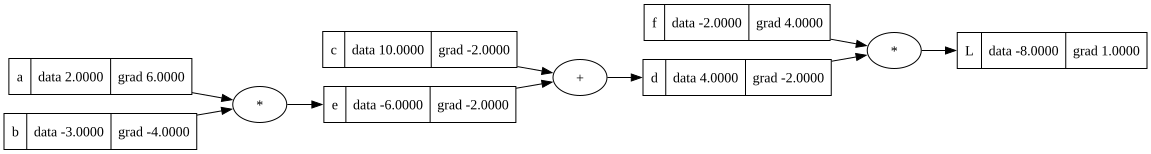

In [7]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = 6.0
b.grad = -4.0
draw_dot(L)

In [8]:
def lol():

    h = 0.0001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b;e.label='e'
    d = e + c;d.label='d'
    f = Value(-2.0, label='f')
    L = d * f;L.label='L'
    L1 = L.data

    a = Value(2.0+h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b;e.label='e'
    d = e + c;d.label='d'
    f = Value(-2.0, label='f')
    L = d * f;L.label='L'
    L2 = L.data

    print((L2-L1)/h)
lol()

6.000000000021544


In [9]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad
e = a * b
d = e + c
L = d * f
print(L.data)

-7.286496


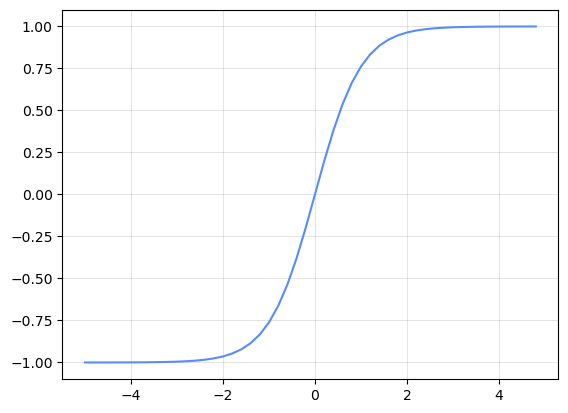

In [10]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5 ,0.2)));plt.grid();

In [11]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh();o.label= 'o'

In [12]:
o.grad = 1#do/do
n.grad = 0.5#do/dn=1-tanh(n)**2

In [13]:
x1w1x2w2.grad = 0.5#do/d(x1*w1+x2*w2)=do/dn*dn/d(x1*w1+x2*w2)=0.5*1=0.5
b.grad = 0.5#do/db=do/dn*dn/db=0.5*1=0.5

In [14]:
#do/d(x1*w1)=do/dn*dn/(x1*w1+x2*w2)*d(x1*w1+x2*w2)/d(x1*w1)=0.5*1=0.5
x1w1.grad = 0.5
#do/d(x1*w1)=do/dn*dn/(x1*w1+x2*w2)*d(x1*w1+x2*w2)/d(x2*w2)=0.581=0.5
x2w2.grad = 0.5

In [15]:
#do/dx1=0.5*(-3);do/dw1=0.5*2=1
x1.grad = -1.5
w1.grad = 1
#do/dx2=0.5*1=0.5;do/dw2=0.5*0=0
x2.grad = 0.5
w2.grad = 0

In [16]:
o.grad=1
o._backward()

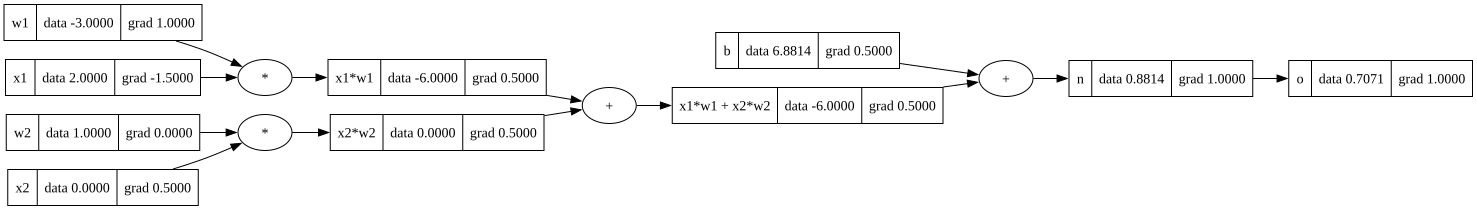

In [17]:
draw_dot(o)

In [18]:
topo = []#拓扑序列
visited = set()#已访问节点的集合
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [19]:
o.grad = 1.0
topo = []#拓扑序列
visited = set()#已访问节点的集合
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
for node in reversed(topo):
    node._backward()

In [20]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad=0.0
        self._backward=lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad=1*out.grad
            other.grad=1*out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad=other.data*out.grad
            other.grad=self.data*out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self*other
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ))
        def _backward():
            self.grad=(1-t**2) * out.grad
        out._backward = _backward
        return out
    def backward(self):
        topo = []#拓扑序列
        visited = set()#已访问节点的集合
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

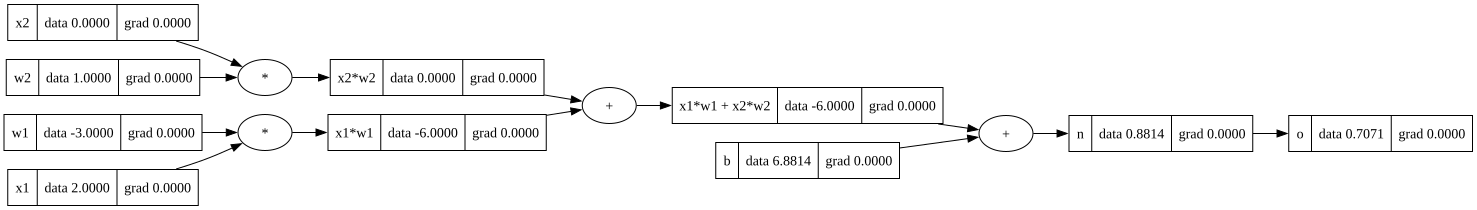

In [21]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh();o.label= 'o'
draw_dot(o)

In [22]:
o.backward()

In [23]:
#重开
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#只在 Jupyter Notebook / IPython 里有效
# matplotlib 画的图内嵌显示在 notebook 输出里，而不是弹出一个独立窗口。

In [24]:
#上面代码构建了一个数据结构，可以了解由哪些元素进行了何种运算，构成现在的结果
#但是对于过于复杂的数学表达式，无法直观看出，因此需要可视化帮助
import os
os.environ["PATH"] = r"E:\develop\Graphviz\bin" + os.pathsep + os.environ["PATH"]
from graphviz import Digraph
#从 root 开始，深度优先遍历整个图。root在此处表示运算的终点
def trace(root):
    #nodes收集所有可达的Value对象
    #edges 收集有向边 (child, v)，方向是「孩子 → 父节点」，也就是数据流动的方向。
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    #建一个有向图，输出格式svg，graph_attr表示格局是从左到右
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #, node_attr={'rankdir': 'TB'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [25]:
#第三版，为了知道结果的字节点有哪些，设置了_children，并将其放入集合_prev中。
#但是仍然不知道子节点进行了何种操作得出父节点，因此再添加一个_op。
#为了便于可视化，增加标签label，方便理解变量计算过程。
#为了实现梯度计算，计算出损失函数对于各个权重的导数，增加grad。
#为了实现自动进行梯度计算，增加函数backward
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad=0.0
        self._backward=lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1*out.grad
            other.grad += 1*out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self*(-1)
        
    def __sub__(self, other):
        return self+(-other)

    def __radd__(self, other):
        return self+other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other,(int, float)),"仅支持int/float类型"
        out = Value(self.data**other, (self,),f"**{other}")
        def _backward():
            self.grad += other*self.data**(other-1)*out.grad
        out._backward = _backward
        return out
        
    def __rmul__(self, other):
        return self*other
        
    def __truediv__(self, other):
        return self*other**-1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ))
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data*out.grad#math.exp(x)*out.grad
        out._backward = _backward
        return out
        
    def backward(self):
        self.grad = 1.0
        topo = []#拓扑序列
        visited = set()#已访问节点的集合
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        for node in reversed(topo):
            node._backward()

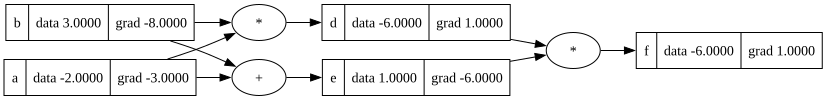

In [26]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b;d.label = 'd'
e = a + b;e.label = 'e'
f = d * e;f.label = 'f'
f.backward()
draw_dot(f)

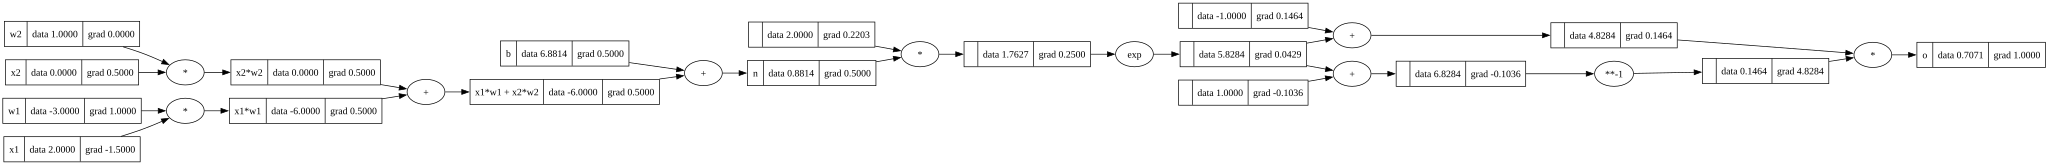

In [27]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'
o.backward()
draw_dot(o)

In [28]:
import torch
import random
x1 = torch.Tensor([2.0]).double();x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double();b.requires_grad = True
n = x1*w1 + x2*w2 +b
o = torch.tanh(n)

print(o.data.item())
o.backward()
print("----------")
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
----------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [29]:
#nin:number of inputs 
import random
class Neuron:
    def __init__(self, nin):#nin表示接受几个输入，例如Neuron(3)表示接受三个输入
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)),self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w+[self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params
        #return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    #nin表示每个神经元的权重，nout表示一层有多少个神经元，nouts表示整个网络每一层的神经元个数
    #例如，[3, 5, 3]表示第一层有三个神经元，第二层有五个，最后一层也有三个
    def __init__(self, nin, nouts):
        #sz表示尺寸，例如首个输入有2个特征，nouts=[3,4]，那么会得到列表[2,3,4] 
        sz = [nin] + nouts
        #len(nouts)表示一共有几层，用i选定某一层。MLP为全连接，第一层有nout个神经元，会产生nout个输出，这些会组成一个列表，
        #输入下一层的每一个神经元。由于Layer的输入nin必定和上一个的输出相等，所以满足
        #self.layers是一个列表，每一项表示一个layer对象。例如self.layers=[Layer(2,3),layer(3,1)]
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
x=[2.0, 3.0, -1.0]
n = MLP(3,[4,4,1])
n(x)
len(n.parameters())

41

In [8]:
# draw_dot(n(x))

In [24]:
xs = [[2.0, 3.0, -1.0],
      [3.0, -1.0, 0.5],
      [0.5, 1.0, 1.0],
      [1.0, 1.0, -1.0]
     ]
ys = [1.0, -1.0, -1.0, 1.0]

In [25]:
for k in range(20):
    ypred = [n(x) for x in xs]
    loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)])

    for p in n.parameters():
        p.grad = 0.0
    
    loss.backward()

    for p in n.parameters():
        p.data += -0.05*p.grad

    print(k, loss.data)
print(ypred)
len(n.parameters())

0 2.1619085504004167
1 0.392146052086521
2 0.29227876983802425
3 0.23206988618005792
4 0.19059147202273702
5 0.16052996429364766
6 0.13793256692079997
7 0.12043788145088186
8 0.10655889427468261
9 0.09532036222696863
10 0.08606035141357538
11 0.07831607361058501
12 0.07175551534736863
13 0.06613503582026045
14 0.06127224502391658
15 0.05702817171021281
16 0.05329524708495502
17 0.0499890265726725
18 0.04704237208032325
19 0.044401289110061234
[Value(data=0.9355959954433495), Value(data=-0.8654461527303972), Value(data=-0.9254547698663004), Value(data=0.8711912885073749)]


41

In [26]:
loss.backward()

In [27]:
n.layers[0].neurons[0].w[0].grad#第一层的第一个神经元的第一个权重

0.4158641448642134

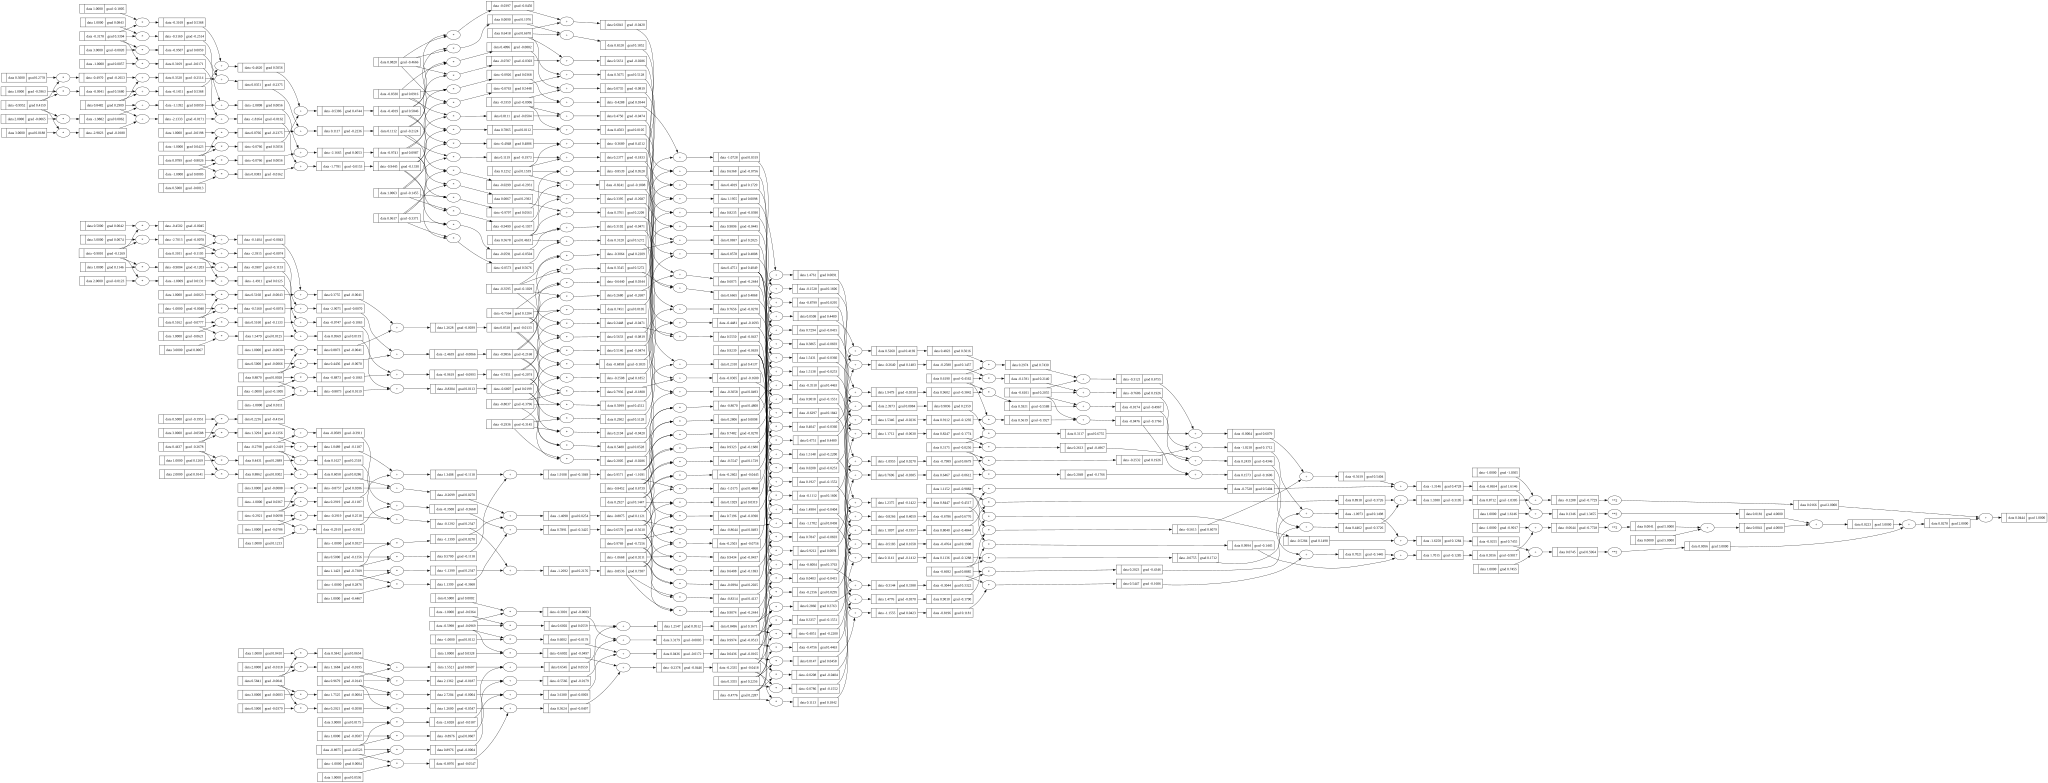

In [28]:
draw_dot(loss)

In [15]:
len(n.parameters())

41

In [16]:
n.layers[0].neurons[0].w[0].data

0.6235924691306217

In [17]:
for p in n.parameters():
    p.data += -0.01*p.grad

In [18]:
n.layers[0].neurons[0].w[0].data

0.6232391041310638

In [19]:
loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=0.09496202795604931)